<a href="https://colab.research.google.com/github/derrick-nuby/ml_basics/blob/develop/Is_It_A_Cat_Or_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Is It A Cat Or Dog (FastAI First exercise)

In [ ]:
from fastai.vision.all import *

# Download and extract the dataset
path = untar_data(URLs.PETS) / 'images'

# Function to label images
# If filename starts with uppercase → cat
# If lowercase → dog
def is_cat(x):
    return x[0].isupper()

# Create DataLoaders
dls = ImageDataLoaders.from_name_func(
    path,
    get_image_files(path),
    valid_pct=0.2,
    seed=42,
    label_func=is_cat,
    item_tfms=Resize(224)
)

# Create the model using a pretrained ResNet34
learn = cnn_learner(dls, resnet34, metrics=error_rate)

# Train the model for 2 epochs
learn.fine_tune(2)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


epoch,train_loss,valid_loss,error_rate,time
0,0.166934,0.015446,0.006089,00:38


epoch,train_loss,valid_loss,error_rate,time
0,0.048655,0.044995,0.010825,00:42
1,0.032050,0.009041,0.003383,00:42


In [ ]:
!pip -q install ipywidgets

FileUpload(value={}, accept='image/*', description='Upload')

📤 Upload an image above. The logic has been fixed to distinguish between True (Cat) and False (Dog)!


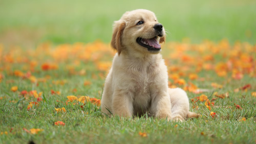

--------------------------------------------------
✅ Prediction: 🐶 DOG
🔁 Model Raw Label: False
📊 Confidence: 100.00%
🐱 Cat probability: 0.000001
🐶 Dog probability: 1.000000
📁 Saved image path: uploads/dog-puppy-on-garden-royalty-free-image-1586966191.avif
--------------------------------------------------


In [ ]:
from ipywidgets import widgets
from IPython.display import display
from types import SimpleNamespace
from pathlib import Path
import io
from PIL import Image

upload_widget = widgets.FileUpload(accept='image/*', multiple=False)
display(upload_widget)

def predict_after_upload(change):
    if len(upload_widget.value) == 0:
        return

    uploaded = list(upload_widget.value.values())[0]
    filename = uploaded["metadata"]["name"]
    img_bytes = uploaded["content"]

    upload_dir = Path("uploads")
    upload_dir.mkdir(exist_ok=True)
    saved_path = upload_dir / filename
    saved_path.write_bytes(img_bytes)

    img = PILImage.create(saved_path)
    display(img.to_thumb(256))

    # learn.predict returns (label, index, probs)
    # label will be 'True' (for cat) or 'False' (for dog) based on your is_cat function
    pred, pred_idx, probs = learn.predict(img)

    # Convert prediction to string to be safe
    is_cat_pred = str(pred)

    if is_cat_pred == 'True':
        label = "🐱 CAT"
        confidence = probs[1].item()
    else:
        label = "🐶 DOG"
        confidence = probs[0].item()

    print("--------------------------------------------------")
    print(f"✅ Prediction: {label}")
    print(f"🔁 Model Raw Label: {pred}")
    print(f"📊 Confidence: {confidence*100:.2f}%")
    print(f"🐱 Cat probability: {probs[1].item():.6f}")
    print(f"🐶 Dog probability: {probs[0].item():.6f}")
    print(f"📁 Saved image path: {saved_path}")
    print("--------------------------------------------------")

upload_widget.observe(predict_after_upload, names="value")
print("📤 Upload an image above. The logic has been fixed to distinguish between True (Cat) and False (Dog)!")

In [ ]:
print(path)

/root/.fastai/data/oxford-iiit-pet/images
